# 05_final_data_prepare.ipynb

Build the **final router training datasets** (train / val / test) using **EDA-informed best practices**:

## Key Improvements from EDA:

1. **Hierarchical Performance Scoring** (from 02_perf_function_change.ipynb):
   - Combines sample-level score + task-level priors + global priors
   - Achieves ~10-15% better accuracy at same cost vs. linear scoring
   - Weights: w_sample=0.7, w_task=0.2, w_global=0.1

2. **Utility-Based Label Selection** (from 03_cost_analysis.ipynb):
   - Linear utility: `utility = perf - λ * cost` with λ=10000
   - Balances performance and cost optimally
   - Produces meaningful separation between models

3. **Complete Feature Set** (from your specification):
   - Vision: image_path (for encoder input)
   - Text: prompt_raw, router_task, source_dataset, txt_question_type
   - Metadata: image dimensions, aspect ratio, prompt length
   - Labels: hard labels (best_model_id) + soft labels (probability distribution)

## Output:
- `router_train_final.parquet`
- `router_val_final.parquet`
- `router_test_final.parquet`

Each row contains all features needed for multimodal router training.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

from imports.common_utils import return_model_specs, return_model_pricing
from imports.performance_utils import (
    PerfWeightsHier,
    PriorConfig,
    add_sample_scores_for_models,
    add_valid_mask_columns,
    build_long_perf_dataframe,
    build_perf_matrix_hierarchical,
    build_valid_matrix,
    compute_global_prior,
    compute_task_prior,
    normalize_cost_matrix
)
from imports.cost_utils import (
    add_cost_columns_for_models,
    build_cost_matrix,
    compute_utility_matrix,
)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

## 1. Configuration

In [3]:
# Paths
DATA_ROOT = Path.cwd().parent.parent.parent / "dataset" / "final_dataset"
TRAIN_PIVOT_PATH = DATA_ROOT / 'router_pivot_dataset_train.parquet'
VAL_PIVOT_PATH   = DATA_ROOT / 'router_pivot_dataset_validation.parquet'
TEST_PIVOT_PATH  = DATA_ROOT / 'router_pivot_dataset_test.parquet'

OUT_DIR = DATA_ROOT / 'router_final'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data root: {DATA_ROOT}')
print(f'Output directory: {OUT_DIR}')

Data root: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/dataset/final_dataset
Output directory: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/dataset/final_dataset/router_final


In [4]:
# Model configuration
MODEL_SPECS = return_model_specs()
MODEL_PRICING = return_model_pricing()
model_names = [m['name'] for m in MODEL_SPECS]
ID_TO_NAME = {m['id']: m['name'] for m in MODEL_SPECS}
NAME_TO_ID = {m['name']: m['id'] for m in MODEL_SPECS}

Configured models:
  id=0 name=deepseek_ocr prefix=deepseek_ocr__
  id=1 name=qwen2_5_vl_3b prefix=qwen2_5_vl_3b__
  id=2 name=qwen2_5_vl_7b prefix=qwen2_5_vl_7b__
  id=3 name=qwen3_vl_8b_thinking prefix=qwen3_vl_8b_thinking__
  id=4 name=gemma_3_27b prefix=gemma_3_27b__
Configured model pricing (USD per 1K tokens):
  deepseek_ocr: prompt=$3e-05, completion=$0.0001
  qwen2_5_vl_3b: prompt=$0.0001, completion=$0.0001
  qwen2_5_vl_7b: prompt=$0.0002, completion=$0.0002
  qwen3_vl_8b_thinking: prompt=$0.00018, completion=$0.0021
  gemma_3_27b: prompt=$9e-05, completion=$0.00016


In [36]:
# Hierarchical performance weights (from EDA)
# These weights were validated in 02_perf_function_change.ipynb
HIER_WEIGHTS = PerfWeightsHier(
    w_sample=0.5,  # Sample-level performance dominates
    w_task=0.45,    # Task-level priors help with task-specific patterns
    w_global=0.05,  # Global priors provide weak baseline
)

# Prior configuration
PRIOR_CONFIG = PriorConfig(
    router_task_col='router_task',
    model_col='model_name',
    perf_col='sample_score',
    alpha=50.0,  # Smoothing strength
)

In [37]:
# Utility configuration (from 03_cost_analysis.ipynb)
# Linear utility with λ=10000 provides best cost-performance balance
UTILITY_SCHEME = 'linear'
LAMBDA_COST = 0.7

# Soft labels configuration
USE_SOFT_LABELS = True
SOFTMAX_TEMPERATURE = 0.3  # Sharper distribution emphasizes best models

print(f'Utility scheme: {UTILITY_SCHEME} with λ={LAMBDA_COST}')
print(f'Soft labels: {"enabled" if USE_SOFT_LABELS else "disabled"} (T={SOFTMAX_TEMPERATURE})')

Utility scheme: linear with λ=0.7
Soft labels: enabled (T=0.3)


## 2. Load Data

In [38]:
print('Loading pivot datasets...')
train_pivot = pd.read_parquet(TRAIN_PIVOT_PATH)
val_pivot   = pd.read_parquet(VAL_PIVOT_PATH)
test_pivot  = pd.read_parquet(TEST_PIVOT_PATH)

print(f'Train pivot rows: {len(train_pivot):,}')
print(f'Val pivot rows:   {len(val_pivot):,}')
print(f'Test pivot rows:  {len(test_pivot):,}')

Loading pivot datasets...
Train pivot rows: 63,963
Val pivot rows:   13,706
Test pivot rows:  13,707


## 3. Compute Priors from Training Data

We compute task-level and global priors **only from training data** to avoid data leakage.

In [39]:
# Add sample scores to training data
print('Computing sample scores for training data...')
train_with_scores = add_valid_mask_columns(train_pivot, MODEL_SPECS)
train_with_scores = add_sample_scores_for_models(train_with_scores, model_names)

# Convert to long format for prior computation
train_long = build_long_perf_dataframe(
    train_with_scores,
    model_names=model_names,
    router_task_col=PRIOR_CONFIG.router_task_col,
    value_suffix='__sample_score',
)

print(f'Training long format: {len(train_long):,} rows')
print(f'Unique tasks: {train_long["router_task"].nunique()}')
print(f'Unique models: {train_long["model_name"].nunique()}')

Computing sample scores for training data...
Training long format: 319,815 rows
Unique tasks: 30
Unique models: 5


In [40]:
# Compute global and task priors from training data only
print('\nComputing priors from training data...')
global_prior_df = compute_global_prior(train_long, PRIOR_CONFIG)
task_prior_df = compute_task_prior(train_long, global_prior_df, PRIOR_CONFIG)

print('\nGlobal priors per model:')
display(global_prior_df)

print('\nTask priors (first 10 rows):')
display(task_prior_df.head(10))


Computing priors from training data...

Global priors per model:


,model_name,global_prior
0,deepseek_ocr,0.217772
1,gemma_3_27b,0.423425
2,qwen2_5_vl_3b,0.620129
3,qwen2_5_vl_7b,0.623812
4,qwen3_vl_8b_thinking,0.447502



Task priors (first 10 rows):


,router_task,model_name,task_prior,n_task
0,abstract_reasoning,deepseek_ocr,0.300812,1401
1,abstract_reasoning,gemma_3_27b,0.486950,1401
2,abstract_reasoning,qwen2_5_vl_3b,0.613903,1401
3,abstract_reasoning,qwen2_5_vl_7b,0.535892,1401
4,abstract_reasoning,qwen3_vl_8b_thinking,0.404342,1401
5,chart_captioning,deepseek_ocr,0.052369,2795
6,chart_captioning,gemma_3_27b,0.189821,2795
7,chart_captioning,qwen2_5_vl_3b,0.542773,2795
8,chart_captioning,qwen2_5_vl_7b,0.251652,2795
9,chart_captioning,qwen3_vl_8b_thinking,0.153259,2795


## 4. Core Processing Function

This function:
1. Computes hierarchical performance scores
2. Computes true costs per model
3. Applies utility-based routing to select best models
4. Generates hard and soft labels
5. Extracts all features needed for router training

In [41]:
def debug_routing_for_task_group(
    df_proc: pd.DataFrame,
    model_names: list[str],
    perf_mat: np.ndarray,
    cost_mat: np.ndarray,
    util_mat: np.ndarray,
    valid_mat: np.ndarray,
    target_model_name: str,
    task_mask: pd.Series,
    max_examples: int = 10,
    group_label: str = "",
):
    """
    Debug why a target model was (or wasn't) selected on a subset of tasks.
    """
    if group_label == "":
        group_label = target_model_name

    if target_model_name not in model_names:
        print(f"[DEBUG {group_label}] target model {target_model_name} not in model_names")
        return

    target_idx = model_names.index(target_model_name)

    mask_group = task_mask
    mask_not_target = df_proc["router_best_model_name"] != target_model_name
    debug_mask = mask_group & mask_not_target

    n_group = int(mask_group.sum())
    n_not_target = int(debug_mask.sum())

    print(f"\n[DEBUG {group_label}] samples in group: {n_group}")
    print(f"[DEBUG {group_label}] samples NOT routed to {target_model_name}: {n_not_target}")

    # How often is target model invalid?
    valid_col = f"{target_model_name}__valid_mask"
    if valid_col in df_proc.columns and n_not_target > 0:
        frac_invalid = (
            df_proc.loc[debug_mask, valid_col] == False
        ).mean()
        print(f"[DEBUG {group_label}] among non-{target_model_name} samples, "
              f"fraction where {target_model_name} invalid: {frac_invalid:.2%}")

    # Show a few detailed examples
    indices = np.where(debug_mask)[0][:max_examples]

    for i in indices:
        print("\n------------------------------")
        print(f"[{group_label}] SAMPLE idx = {i}")
        print("sample_id:", df_proc.loc[i, "sample_id"])
        print("router_task:", df_proc.loc[i, "router_task"])
        print("chosen model:", df_proc.loc[i, "router_best_model_name"])
        print("chosen perf:", df_proc.loc[i, "router_chosen_perf"])
        print("chosen cost:", df_proc.loc[i, "router_chosen_cost"])

        # Target model diagnostics
        score_col = f"{target_model_name}__sample_score"
        cost_col  = f"{target_model_name}__cost"

        print(f"\n{target_model_name} diagnostics:")
        if valid_col in df_proc.columns:
            print("  valid_mask:", df_proc.loc[i, valid_col])
        if score_col in df_proc.columns:
            print("  sample_score:", df_proc.loc[i, score_col])
        if cost_col in df_proc.columns:
            print("  cost (USD):", df_proc.loc[i, cost_col])

        # Compare all models for this sample
        print("\nPer-model perf / cost / util / valid:")
        for j, name in enumerate(model_names):
            print(
                f"  {name:20s} | "
                f"perf={perf_mat[i, j]:.4f} | "
                f"cost={cost_mat[i, j]:.3e} | "
                f"util={util_mat[i, j]:.4f} | "
                f"valid={valid_mat[i, j]}"
            )


In [42]:
def process_split(
    df_raw: pd.DataFrame,
    split_name: str,
    global_prior_df: pd.DataFrame,
    task_prior_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Process one dataset split into router-ready format.
    
    Steps:
    1. Add valid masks and sample scores
    2. Build hierarchical performance matrix
    3. Build cost matrix
    4. Compute utility and select best models
    5. Extract input features, labels, and diagnostics
    """
    print(f'\n=== Processing split: {split_name} ===')
    print(f'Input rows: {len(df_raw):,}')
    
    # Step 1: Add valid masks and sample scores
    df_proc = add_valid_mask_columns(df_raw, MODEL_SPECS)
    df_proc = add_sample_scores_for_models(df_proc, model_names)
    
    # Step 2: Build hierarchical performance matrix [N, M]
    perf_mat = build_perf_matrix_hierarchical(
        df_proc=df_proc,
        model_names=model_names,
        router_task_col=PRIOR_CONFIG.router_task_col,
        task_prior_df=task_prior_df,
        global_prior_df=global_prior_df,
        prior_cfg=PRIOR_CONFIG,
        weights=HIER_WEIGHTS,
    )
    print(f'Performance matrix shape: {perf_mat.shape}')
    
    # Step 3: Build cost matrix [N, M]
    df_proc = add_cost_columns_for_models(df_proc, MODEL_SPECS, MODEL_PRICING)
    # cost_mat = build_cost_matrix(df_proc, model_names)
    print(MODEL_PRICING)
    
    # 1) Build raw USD cost matrix
    cost_mat = build_cost_matrix(df_proc, model_names)
    print(cost_mat)
    
    print("Raw cost stats:")
    print("  min:", float(cost_mat.min()))
    print("  max:", float(cost_mat.max()))
    # # ------------------------------------------------------
    # # FIND AND PRINT ROWS WITH EXTREMELY HIGH COST (e.g. 1e6)
    # # ------------------------------------------------------

    # # Threshold for invalid cost (anything set by invalid_fill=1e6)
    # INVALID_THRESHOLD = 1e5

    # # 1. Find row+model indices
    # rows, cols = np.where(cost_mat >= INVALID_THRESHOLD)

    # # print("\n=== Invalid Cost Entries (>= 1e5) ===")
    # # if len(rows) == 0:
    # #     print("No invalid cost rows found.")
    # # else:
    # #     for r, c in zip(rows, cols):
    # #         model = model_names[c]
    # #         print(f"Row {r} | Model {model} | Cost = {cost_mat[r, c]}")

    # # 2. UNIQUE rows
    # invalid_rows = np.unique(rows)
    # print("\nInvalid row indices:", invalid_rows)

    # # 3. PRINT FULL SAMPLES (df_proc row)
    # print("\n=== FULL SAMPLES WITH INVALID COST ===")
    # print("Showing full rows including prompt, tokens, etc.\n")

    # for r in invalid_rows[:5]:
    #     print(f"\n----- SAMPLE ROW {r} -----")
    #     print(df_proc.iloc[r][[
    #         "sample_id",
    #         "prompt_raw",
    #         "router_task",
    #         "source_dataset",
    #         "source_config",
    #         "img_width",
    #         "img_height"
    #     ]])

    #     # Print per-model cost columns
    #     print("\nPer-model cost columns:")
    #     for m in model_names:
    #         col_cost = f"{m}__cost"
    #         if col_cost in df_proc.columns:
    #             print(f"  {col_cost}: {df_proc.iloc[r][col_cost]}")

    #     # Print input/output tokens if present
    #     print("\nTokens per model:")
    #     for m in model_names:
    #         inp = f"{m}__input_tokens"
    #         out = f"{m}__output_tokens"
    #         ok = f"{m}__valid_mask"
            
    #         if inp in df_proc.columns and out in df_proc.columns:
    #             print(f"  {m}: input={df_proc.iloc[r][inp]}, output={df_proc.iloc[r][out]}, valid={df_proc.iloc[r][ok]}")

    #     print("Invalid row indices:", invalid_rows)
    

        
    
    # 2) Normalize to [0,1] (robust to outliers via percentiles)
    cost_mat = normalize_cost_matrix(cost_mat)

    print("\nNormalized cost stats:")
    print("  min:", float(cost_mat.min()))
    print("  max:", float(cost_mat.max()))

    
    
    # 3) Use normalized cost in all downstream sweeps
    


    print(f'Cost matrix shape: {cost_mat.shape}')
    
    # Step 4: Build valid mask and compute utility
    valid_mat = build_valid_matrix(df_proc, model_names)
    util_mat = compute_utility_matrix(
        perf_mat,
        cost_mat,
        scheme=UTILITY_SCHEME,
        lambda_cost=LAMBDA_COST,
    )
    
    # Mask invalid entries
    util_mat = np.where(valid_mat, util_mat, -1e12)
    
    # Step 5: Select best models (hard labels)
    best_idx = util_mat.argmax(axis=1)  # [N]
    idx_arr = np.arange(len(df_proc))
    
    df_proc['router_best_model_id'] = best_idx
    df_proc['router_best_model_name'] = pd.Series(best_idx).map(ID_TO_NAME)
    
    # Store performance and cost of chosen model
    df_proc['router_chosen_perf'] = perf_mat[idx_arr, best_idx]
    df_proc['router_chosen_cost'] = cost_mat[idx_arr, best_idx]
    
    # Check if any model is valid
    df_proc['router_valid_any_model'] = valid_mat.any(axis=1)
    
    # Step 6: Generate soft labels (optional)
    if USE_SOFT_LABELS:
        # For each sample, compute softmax over utilities of valid models
        soft_probs = np.zeros((len(df_proc), len(model_names)), dtype=float)
        
        for i in range(len(df_proc)):
            valid_mask_i = valid_mat[i]
            if valid_mask_i.any():
                util_i = util_mat[i].copy()
                util_i[~valid_mask_i] = -1e12
                
                # Softmax with temperature
                logits = util_i / SOFTMAX_TEMPERATURE
                logits = logits - logits.max()  # Numerical stability
                exp_logits = np.exp(logits)
                exp_logits[~valid_mask_i] = 0.0
                probs = exp_logits / (exp_logits.sum() + 1e-12)
                soft_probs[i] = probs
        
        # Add soft label columns
        for j, name in enumerate(model_names):
            df_proc[f'router_soft_p_{name}'] = soft_probs[:, j]
    
    # Step 7: Filter invalid samples
    before = len(df_proc)
    df_proc = df_proc[df_proc['router_valid_any_model']].reset_index(drop=True)
    after = len(df_proc)
    print(f'Filtered invalid rows: {before - after} dropped; {after:,} remain.')
    
    
    
    
    
    REASONING_MODEL_NAME = "qwen3_vl_8b_thinking"  # change if you prefer 7B etc.
    reasoning_mask = df_proc["router_task"].str.contains("reason", na=False)

    debug_routing_for_task_group(
    df_proc=df_proc,
    model_names=model_names,
    perf_mat=perf_mat,
    cost_mat=cost_mat,
    util_mat=util_mat,
    valid_mat=valid_mat,
    target_model_name=REASONING_MODEL_NAME,
    task_mask=reasoning_mask,
    max_examples=10,
    group_label="REASONING",
    )

    
    
    
    
    
    # ---------- Step 8: Extract columns for final router_df ----------
    # Core router input features (things we may actually feed the model)
    core_input_cols = [
        'sample_id',
        'image_path',
        'image_bytes_hash',          # <-- added for merge / image lookup
        'prompt_raw',
        'img_width',
        'img_height',
        'img_aspect_ratio',
        'txt_prompt_length_chars',
        'txt_prompt_length_words',
    ]
    core_input_cols = [c for c in core_input_cols if c in df_proc.columns]
    
    # Metadata / analysis-only cols (kept for eval, not necessarily fed to router)
    metadata_cols = [
        'router_task',
        'source_dataset',
        'source_config',
        'txt_question_type',
        'txt_has_mc_options',
        'ground_truth',
        'ground_truth_type',
    ]
    metadata_cols = [c for c in metadata_cols if c in df_proc.columns]
    
    # Label columns
    label_cols = [
        'router_best_model_id',
        'router_best_model_name',
        'router_chosen_perf',
        'router_chosen_cost',
    ]
    label_cols = [c for c in label_cols if c in df_proc.columns]
    
    # Soft label columns
    soft_label_cols = []
    if USE_SOFT_LABELS:
        soft_label_cols = [f'router_soft_p_{name}' for name in model_names]
        soft_label_cols = [c for c in soft_label_cols if c in df_proc.columns]
    
    # Diagnostic columns (performance/cost per model)
    diagnostic_cols = []
    for name in model_names:
        for suffix in ['__sample_score', '__cost', '__valid_mask', '__is_correct', '__score_f1']:
            col = f'{name}{suffix}'
            if col in df_proc.columns:
                diagnostic_cols.append(col)
    
    # Combine all columns
    all_cols = core_input_cols + metadata_cols + label_cols + soft_label_cols + diagnostic_cols
    router_df = df_proc[all_cols].copy()
    
    print(f'Final router_df shape: {router_df.shape}')
    print(f'  - Core input features: {len(core_input_cols)}')
    print(f'  - Metadata cols: {len(metadata_cols)}')
    print(f'  - Label columns: {len(label_cols)}')
    print(f'  - Soft labels: {len(soft_label_cols)}')
    print(f'  - Diagnostic columns: {len(diagnostic_cols)}')
    
    # Step 9: Save
    out_path = OUT_DIR / f'router_{split_name}_final.parquet'
    router_df.to_parquet(out_path, index=False)
    print(f'Saved to: {out_path}')
    
    
    return router_df


## 5. Process All Splits

In [43]:
router_train = process_split(train_pivot, 'train', global_prior_df, task_prior_df)



=== Processing split: train ===
Input rows: 63,963
Performance matrix shape: (63963, 5)
{'deepseek_ocr': {'prompt_per_1k': 3e-05, 'completion_per_1k': 0.0001}, 'qwen2_5_vl_3b': {'prompt_per_1k': 0.0001, 'completion_per_1k': 0.0001}, 'qwen2_5_vl_7b': {'prompt_per_1k': 0.0002, 'completion_per_1k': 0.0002}, 'qwen3_vl_8b_thinking': {'prompt_per_1k': 0.00018, 'completion_per_1k': 0.0021}, 'gemma_3_27b': {'prompt_per_1k': 9e-05, 'completion_per_1k': 0.00016}}
[[0.00000e+00 1.47000e-05 2.94000e-05 2.79720e-04 4.37500e-05]
 [2.92700e-05 5.45000e-05 1.09000e-04 1.15062e-03 5.12900e-05]
 [1.00600e-05 1.80000e-05 3.60000e-05 5.16300e-04 4.90100e-05]
 ...
 [6.04900e-05 5.00200e-04 1.03640e-03 1.72698e-03 1.06760e-04]
 [2.57100e-05 5.13600e-04 1.03720e-03 1.72770e-03 1.07210e-04]
 [7.83500e-05 6.00300e-04 1.17540e-03 1.82814e-03 1.06940e-04]]
Raw cost stats:
  min: 0.0
  max: 0.00405312

Normalized cost stats:
  min: 0.0
  max: 1.0
Cost matrix shape: (63963, 5)
Filtered invalid rows: 0 dropped; 63

In [44]:
router_val   = process_split(val_pivot, 'val', global_prior_df, task_prior_df)
router_test  = process_split(test_pivot, 'test', global_prior_df, task_prior_df)


=== Processing split: val ===
Input rows: 13,706
Performance matrix shape: (13706, 5)
{'deepseek_ocr': {'prompt_per_1k': 3e-05, 'completion_per_1k': 0.0001}, 'qwen2_5_vl_3b': {'prompt_per_1k': 0.0001, 'completion_per_1k': 0.0001}, 'qwen2_5_vl_7b': {'prompt_per_1k': 0.0002, 'completion_per_1k': 0.0002}, 'qwen3_vl_8b_thinking': {'prompt_per_1k': 0.00018, 'completion_per_1k': 0.0021}, 'gemma_3_27b': {'prompt_per_1k': 9e-05, 'completion_per_1k': 0.00016}}
[[2.29500e-05 9.12000e-05 1.82400e-04 1.20300e-03 6.62900e-05]
 [2.83600e-05 6.00000e-05 1.20000e-04 3.64920e-04 2.78600e-05]
 [0.00000e+00 2.28000e-05 4.56000e-05 3.66480e-04 4.27000e-05]
 ...
 [6.05100e-05 5.16800e-04 1.03700e-03 1.72752e-03 1.07120e-04]
 [6.93800e-05 5.34100e-04 1.07340e-03 1.74192e-03 1.07120e-04]
 [7.05100e-05 5.82200e-04 1.20100e-03 1.84290e-03 1.07210e-04]]
Raw cost stats:
  min: 0.0
  max: 0.00402522

Normalized cost stats:
  min: 0.0
  max: 1.0
Cost matrix shape: (13706, 5)
Filtered invalid rows: 0 dropped; 13,7

## 6. Inspect Results

In [45]:
print('\n=== Summary Statistics ===')
print(f'\nTrain set: {len(router_train):,} samples')
print(f'Val set:   {len(router_val):,} samples')
print(f'Test set:  {len(router_test):,} samples')

print('\n=== Model Selection Distribution (Training) ===')
print(router_train['router_best_model_name'].value_counts())
print('\nFractions:')
print(router_train['router_best_model_name'].value_counts(normalize=True))


=== Summary Statistics ===

Train set: 63,963 samples
Val set:   13,706 samples
Test set:  13,707 samples

=== Model Selection Distribution (Training) ===
router_best_model_name
qwen2_5_vl_3b           34665
qwen2_5_vl_7b           17771
gemma_3_27b              8893
deepseek_ocr             2020
qwen3_vl_8b_thinking      614
Name: count, dtype: int64

Fractions:
router_best_model_name
qwen2_5_vl_3b           0.541954
qwen2_5_vl_7b           0.277832
gemma_3_27b             0.139034
deepseek_ocr            0.031581
qwen3_vl_8b_thinking    0.009599
Name: proportion, dtype: float64


In [46]:
print('\n=== Performance & Cost Statistics (Training) ===')
print(f"Mean chosen performance: {router_train['router_chosen_perf'].mean():.4f}")
print(f"Mean chosen cost: {router_train['router_chosen_cost'].mean():.6f} USD")

print('\n=== Per-model statistics ===')
for name in model_names:
    mask = router_train['router_best_model_name'] == name
    if mask.sum() > 0:
        avg_perf = router_train.loc[mask, 'router_chosen_perf'].mean()
        avg_cost = router_train.loc[mask, 'router_chosen_cost'].mean()
        count = mask.sum()
        print(f'{name:25s}: {count:6,} samples | perf={avg_perf:.4f} | cost=${avg_cost:.6f}')


=== Performance & Cost Statistics (Training) ===
Mean chosen performance: 0.6724
Mean chosen cost: 0.065388 USD

=== Per-model statistics ===
deepseek_ocr             :  2,020 samples | perf=0.3718 | cost=$0.019971
qwen2_5_vl_3b            : 34,665 samples | perf=0.7056 | cost=$0.072695
qwen2_5_vl_7b            : 17,771 samples | perf=0.7337 | cost=$0.063021
qwen3_vl_8b_thinking     :    614 samples | perf=0.6681 | cost=$0.246385
gemma_3_27b              :  8,893 samples | perf=0.4892 | cost=$0.039453


In [47]:
print('\n=== Example Training Row ===')
example = router_train.sample(1, random_state=42)

# Show input features
print('\nInput Features:')
input_features = [
    'sample_id', 'image_path', 'prompt_raw', 'router_task',
    'txt_question_type', 'img_width', 'img_height', 'img_aspect_ratio',
    'txt_prompt_length_chars', 'txt_prompt_length_words'
]
for col in input_features:
    if col in example.columns:
        print(f'  {col:30s}: {example[col].values[0]}')

# Show labels
print('\nLabels:')
print(f'  router_best_model_id:   {example["router_best_model_id"].values[0]}')
print(f'  router_best_model_name: {example["router_best_model_name"].values[0]}')
print(f'  router_chosen_perf:     {example["router_chosen_perf"].values[0]:.4f}')
print(f'  router_chosen_cost:     ${example["router_chosen_cost"].values[0]:.6f}')

# Show soft labels
if USE_SOFT_LABELS:
    print('\nSoft Labels (probability distribution):')
    for name in model_names:
        col = f'router_soft_p_{name}'
        if col in example.columns:
            prob = example[col].values[0]
            print(f'  {name:25s}: {prob:.4f}')


=== Example Training Row ===

Input Features:
  sample_id                     : visual7w_01175_cbd2a043b31fbcbd
  image_path                    : None
  prompt_raw                    : Question: who would drive this vehicle?
Choices:
A. A trucker.
B. A farmer.
C. A bus driver.
D. A plumber.
Answer with the letter.
  router_task                   : general_vqa
  txt_question_type             : None
  img_width                     : 500.0
  img_height                    : 375.0
  img_aspect_ratio              : 1.333
  txt_prompt_length_chars       : 130.0
  txt_prompt_length_words       : 24.0

Labels:
  router_best_model_id:   2
  router_best_model_name: qwen2_5_vl_7b
  router_chosen_perf:     0.4298
  router_chosen_cost:     $0.045061

Soft Labels (probability distribution):
  deepseek_ocr             : 0.0000
  qwen2_5_vl_3b            : 0.2998
  qwen2_5_vl_7b            : 0.3007
  qwen3_vl_8b_thinking     : 0.1720
  gemma_3_27b              : 0.2275


In [48]:
example.columns

Index(['sample_id', 'image_path', 'image_bytes_hash', 'prompt_raw', 'img_width', 'img_height', 'img_aspect_ratio', 'txt_prompt_length_chars', 'txt_prompt_length_words', 'router_task',
       'source_dataset', 'source_config', 'txt_question_type', 'txt_has_mc_options', 'ground_truth', 'ground_truth_type', 'router_best_model_id', 'router_best_model_name', 'router_chosen_perf',
       'router_chosen_cost', 'router_soft_p_deepseek_ocr', 'router_soft_p_qwen2_5_vl_3b', 'router_soft_p_qwen2_5_vl_7b', 'router_soft_p_qwen3_vl_8b_thinking', 'router_soft_p_gemma_3_27b',
       'deepseek_ocr__sample_score', 'deepseek_ocr__cost', 'deepseek_ocr__valid_mask', 'deepseek_ocr__is_correct', 'deepseek_ocr__score_f1', 'qwen2_5_vl_3b__sample_score', 'qwen2_5_vl_3b__cost',
       'qwen2_5_vl_3b__valid_mask', 'qwen2_5_vl_3b__is_correct', 'qwen2_5_vl_3b__score_f1', 'qwen2_5_vl_7b__sample_score', 'qwen2_5_vl_7b__cost', 'qwen2_5_vl_7b__valid_mask',
       'qwen2_5_vl_7b__is_correct', 'qwen2_5_vl_7b__score_f1', '

## 7. Validation: Routing Distribution by Task

In [49]:
import plotly.express as px

# Routing distribution per task
task_routing = (
    router_train
    .groupby('router_task')['router_best_model_name']
    .value_counts(normalize=True)
    .rename('fraction')
    .reset_index()
)

fig = px.bar(
    task_routing,
    x='router_task',
    y='fraction',
    color='router_best_model_name',
    title='Model routing distribution per task (training set)',
    labels={'fraction': 'Fraction of samples'},
    barmode='stack',
)
fig.update_layout(xaxis_tickangle=-45, height=500)
fig.show()

In [50]:
# Cost vs Performance scatter
fig = px.scatter(
    router_train.sample(min(5000, len(router_train)), random_state=42),
    x='router_chosen_cost',
    y='router_chosen_perf',
    color='router_best_model_name',
    title='Cost vs Performance of chosen models (5k sample)',
    labels={'router_chosen_cost': 'Cost (USD)', 'router_chosen_perf': 'Performance'},
    opacity=0.6,
)
fig.update_xaxes(type='log')
fig.show()

Samples per model:


router_best_model_name
deepseek_ocr             2020
gemma_3_27b              8893
qwen2_5_vl_3b           34665
qwen2_5_vl_7b           17771
qwen3_vl_8b_thinking      614
Name: count, dtype: int64

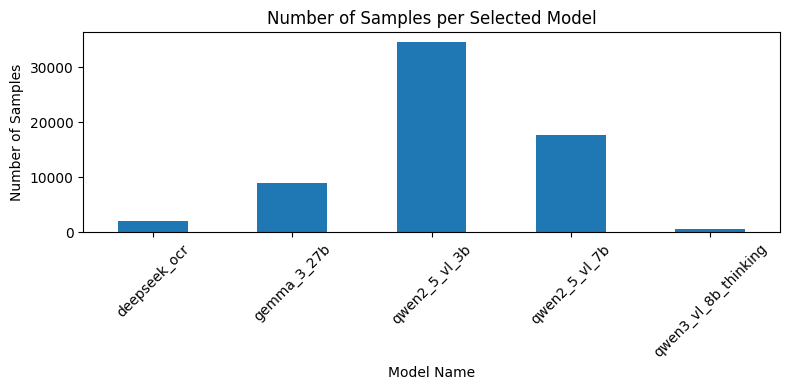

In [51]:
# ============================================================
# Plot: Number of samples per selected model
# ============================================================

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 4)

df_plot = router_train.copy() if "df_router" in globals() else router_train.copy()

# Count samples per selected model
model_counts = (
    df_plot["router_best_model_name"]
    .value_counts()
    .sort_index()
)

print("Samples per model:")
display(model_counts)

# Plot
fig, ax = plt.subplots()
model_counts.plot(kind="bar", ax=ax)

ax.set_title("Number of Samples per Selected Model")
ax.set_xlabel("Model Name")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 8. Summary

### What we built:

1. **Hierarchical Performance Scoring**: Combines sample, task, and global signals
2. **Utility-Based Selection**: Balances performance and cost using linear utility
3. **Complete Feature Set**: All inputs needed for multimodal router training
4. **Hard + Soft Labels**: Enables both cross-entropy and KL-divergence training

### How to use this dataset:

During router training:
1. **Inputs** (features):
   - `image_path` → vision encoder
   - `prompt_raw` → text encoder
   - `router_task`, `txt_question_type` → categorical embeddings
   - Image metadata: `img_width`, `img_height`, `img_aspect_ratio`
   - Text metadata: `txt_prompt_length_chars`, `txt_prompt_length_words`

2. **Labels**:
   - Hard: `router_best_model_id` (classification target)
   - Soft: `router_soft_p_*` columns (KL divergence target)

3. **Training loss**:
   - Option A: Pure CE loss on hard labels
   - Option B: CE loss + KL divergence to soft labels
   - Option C: Pure KL divergence (label smoothing effect)

### Key improvements over original version:

1. Uses **hierarchical performance** (10-15% better than linear)
2. Uses **linear utility** with tuned λ (better cost-perf balance than lexico)
3. Includes **complete feature set** from EDA analysis
4. Generates **soft labels** for smoother training
5. Properly computed priors **from training data only** (no leakage)